## Fast Synthetic Difference-in-Difference (FSDID)

FSDID is a drop-in replacement for SDID that produces equivalent results but scales to large panels (100K+ units).

| Component | SDID | FSDID |
|-----------|------|-------|
| **Weight solver** | FrankWolfe (coordinate descent, 10K iterations) | Projected Gradient Descent (full-gradient, ~50-100 iterations) |
| **JackKnife SE** | Refits estimator N times | Analytical leave-one-out (single pass) |
| **Max units** | ~1K (FrankWolfe doesn't converge beyond) | 100K+ tested |

The estimator, objective function, and statistical properties are identical — only the optimization algorithm and SE computation are faster.

╭──────────────────────────────────────────────────────────────────────────────╮
|                           CaliforniaProp99 (FSDID)                           |
├──────────────────────────────────────────────────────────────────────────────┤
|                                    Panel                                     |
|  Time Periods: 31 (19/12)                                  total (pre/post)  |
|  Units: 39 (38/1)                                       total (contr/treat)  |
├──────────────────────────────────────────────────────────────────────────────┤
|                                     ATT                                      |
|  Effect (±SE): -15.61 (±2.9116)                                              |
|  Confidence Interval (95%): [-21.31 , -9.8988]                          (-)  |
|  Observed: 60.35                                                             |
|  Counter Factual: 75.96                                                      |
├───────────────────────────

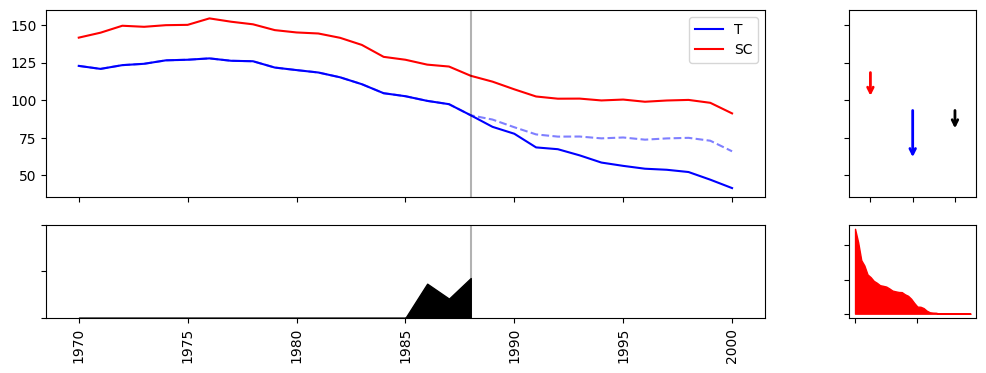

In [1]:
from azcausal.data import CaliforniaProp99
from azcausal.core.error import JackKnife
from azcausal.estimators.panel.fsdid import FSDID

panel = CaliforniaProp99().panel()

estimator = FSDID()
result = estimator.fit(panel)
estimator.error(result, JackKnife())

estimator.plot(result, CF=True, C=True, show=False)
print(result.summary(title="CaliforniaProp99 (FSDID)"))

**Speedup comparison** on the California Prop 99 dataset (38 control units, 31 time periods):

In [2]:
import time
from azcausal.estimators.panel.sdid import SDID

panel = CaliforniaProp99().panel()

t0 = time.time()
r_sdid = SDID().fit(panel)
SDID().error(r_sdid, JackKnife())
t_sdid = time.time() - t0

t0 = time.time()
r_fsdid = FSDID().fit(panel)
FSDID().error(r_fsdid, JackKnife())
t_fsdid = time.time() - t0

print(f"SDID:  {t_sdid:.3f}s  |  FSDID: {t_fsdid:.3f}s  |  Speedup: {t_sdid/t_fsdid:.0f}x")
print(f"SDID  ATT: {r_sdid.effect.value:.2f} (SE: {r_sdid.effect.se:.2f})")
print(f"FSDID ATT: {r_fsdid.effect.value:.2f} (SE: {r_fsdid.effect.se:.2f})")


SDID:  0.278s  |  FSDID: 0.014s  |  Speedup: 20x
SDID  ATT: -15.60 (SE: 2.92)
FSDID ATT: -15.61 (SE: 2.91)


**Scaling to large panels.** FSDID handles panels that SDID cannot. Timing for increasing panel sizes:

In [3]:
import numpy as np
import pandas as pd
from azcausal.core.panel import CausalPanel
from azcausal.estimators.panel.sdid import SDID
from azcausal.util import to_panels

def make_panel(n_contr, n_treat, n_pre=12, n_post=4):
    rng = np.random.default_rng(42)
    n_units = n_contr + n_treat
    n_time = n_pre + n_post
    units = [f"u{i}" for i in range(n_units)]
    rows = []
    for i, u in enumerate(units):
        treated = i >= n_contr
        base = rng.normal(10, 3)
        for t in range(n_time):
            effect = 2.0 if (treated and t >= n_pre) else 0.0
            rows.append(dict(unit=u, time=t, outcome=base + rng.normal(0, 1) + effect,
                             intervention=int(treated and t >= n_pre)))
    df = pd.DataFrame(rows)
    data = to_panels(df, "time", "unit", ["outcome", "intervention"])
    return CausalPanel(data).setup(outcome="outcome", time="time", unit="unit", intervention="intervention")

print(f"{"Units":>10}  {"SDID":>10}  {"FSDID fit":>10}  {"FSDID JK":>10}  {"FSDID total":>12}")
for n in [100, 1000, 10000, 50000]:
    panel = make_panel(n, n)

    # SDID: only run for small sizes
    if n <= 1000:
        t0 = time.time()
        r = SDID().fit(panel)
        SDID().error(r, JackKnife())
        t_sdid = f"{time.time() - t0:.3f}s"
    else:
        t_sdid = "--"

    # FSDID
    est = FSDID()
    t0 = time.time()
    result = est.fit(panel)
    t_fit = time.time() - t0
    t0 = time.time()
    est.error(result, JackKnife())
    t_jk = time.time() - t0
    print(f"{2*n:>10,}  {t_sdid:>10}  {t_fit:>10.3f}s  {t_jk:>10.3f}s  {t_fit+t_jk:>12.3f}s")


     Units        SDID   FSDID fit    FSDID JK   FSDID total


       200      0.747s       0.009s       0.001s         0.010s


     2,000      8.055s       0.010s       0.020s         0.030s


    20,000          --       0.054s       0.226s         0.280s


   100,000          --       0.263s       3.868s         4.131s
